# Поиск контекста для LLM

Соберём retrieval-baseline для RAG: преобразуем документы в TF-IDF-векторы, найдём релевантный контекст по cosine similarity и проанализируем сходство документов и важные термы.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

## Небольшая база знаний

In [2]:
documents = pd.DataFrame([
    ("ml-pipeline", "ML pipeline", "Pipeline объединяет подготовку признаков и модель, снижая риск утечки данных."),
    ("cross-validation", "Cross-validation", "Кросс-валидация оценивает устойчивость модели на нескольких разбиениях выборки."),
    ("classification-metrics", "Classification metrics", "Precision, recall, F1 и ROC-AUC описывают разные стороны качества классификатора."),
    ("embeddings", "Text embeddings", "Текстовые embeddings представляют смысл фрагмента числовым вектором."),
    ("rag", "Retrieval augmented generation", "RAG сначала находит релевантный контекст, затем передаёт его языковой модели."),
    ("vector-database", "Vector database", "Векторная база хранит embeddings и выполняет быстрый поиск ближайших документов."),
    ("prompting", "Prompt design", "Хороший prompt задаёт роль, контекст, ограничения и формат ожидаемого ответа."),
    ("monitoring", "Model monitoring", "Мониторинг отслеживает качество, задержку, ошибки и изменение входных данных."),
    ("chunking", "Document chunking", "Документы делят на небольшие фрагменты, чтобы точнее находить подходящий контекст."),
    ("reranking", "Reranking", "Reranker повторно сортирует найденные документы и повышает точность retrieval-системы."),
], columns=["id", "title", "text"])
documents

,id,title,text
0,ml-pipeline,ML pipeline,Pipeline объединяет подготовку признаков и мод...
1,cross-validation,Cross-validation,Кросс-валидация оценивает устойчивость модели ...
2,classification-metrics,Classification metrics,"Precision, recall, F1 и ROC-AUC описывают разн..."
3,embeddings,Text embeddings,Текстовые embeddings представляют смысл фрагме...
4,rag,Retrieval augmented generation,"RAG сначала находит релевантный контекст, зате..."
5,vector-database,Vector database,Векторная база хранит embeddings и выполняет б...
6,prompting,Prompt design,"Хороший prompt задаёт роль, контекст, ограниче..."
7,monitoring,Model monitoring,"Мониторинг отслеживает качество, задержку, оши..."
8,chunking,Document chunking,"Документы делят на небольшие фрагменты, чтобы ..."
9,reranking,Reranking,Reranker повторно сортирует найденные документ...


## Индексация

In [3]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
document_matrix = vectorizer.fit_transform(documents["text"])

pd.Series({
    "documents": document_matrix.shape[0],
    "features": document_matrix.shape[1],
    "matrix_density": document_matrix.nnz / (document_matrix.shape[0] * document_matrix.shape[1]),
}).to_frame("value")

,value
documents,10.000000
features,163.000000
matrix_density,0.104294


## Поиск

In [4]:
def search(query, limit=3):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, document_matrix).ravel()
    order = scores.argsort()[::-1]
    result = documents.iloc[order][["id", "title", "text"]].copy()
    result["score"] = scores[order]
    return result.head(limit).reset_index(drop=True), scores

query = "как найти контекст для ответа языковой модели"
results, scores = search(query, limit=3)
results

,id,title,text,score
0,rag,Retrieval augmented generation,"RAG сначала находит релевантный контекст, зате...",0.370570
1,prompting,Prompt design,"Хороший prompt задаёт роль, контекст, ограниче...",0.184612
2,cross-validation,Cross-validation,Кросс-валидация оценивает устойчивость модели ...,0.086179


## Релевантность всех документов

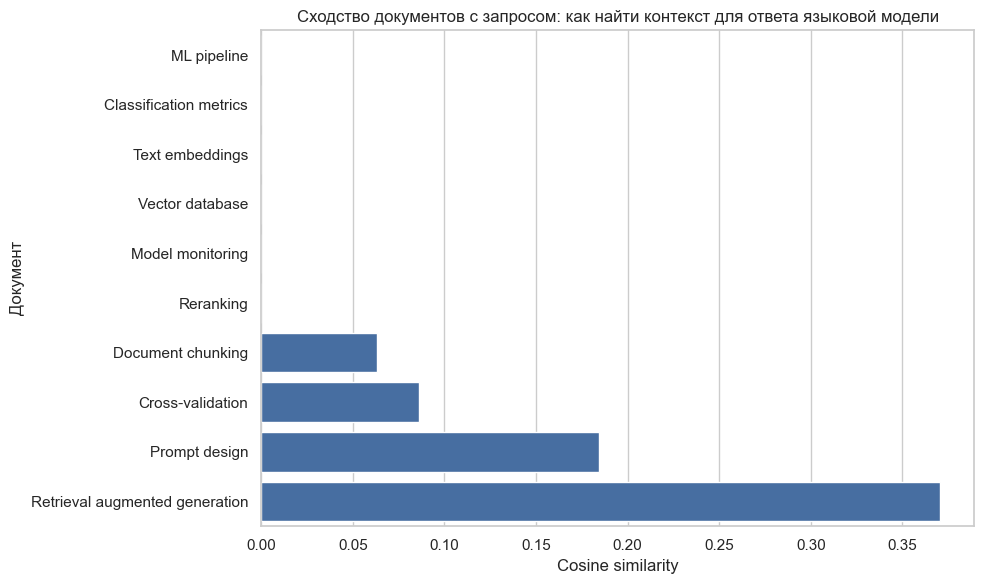

In [5]:
score_frame = documents[["title"]].copy()
score_frame["score"] = scores
score_frame = score_frame.sort_values("score")

plt.figure(figsize=(10, 6))
sns.barplot(data=score_frame, x="score", y="title", color="#386cb0")
plt.title(f"Сходство документов с запросом: {query}")
plt.xlabel("Cosine similarity")
plt.ylabel("Документ")
plt.tight_layout()
plt.show()

## Сходство документов между собой

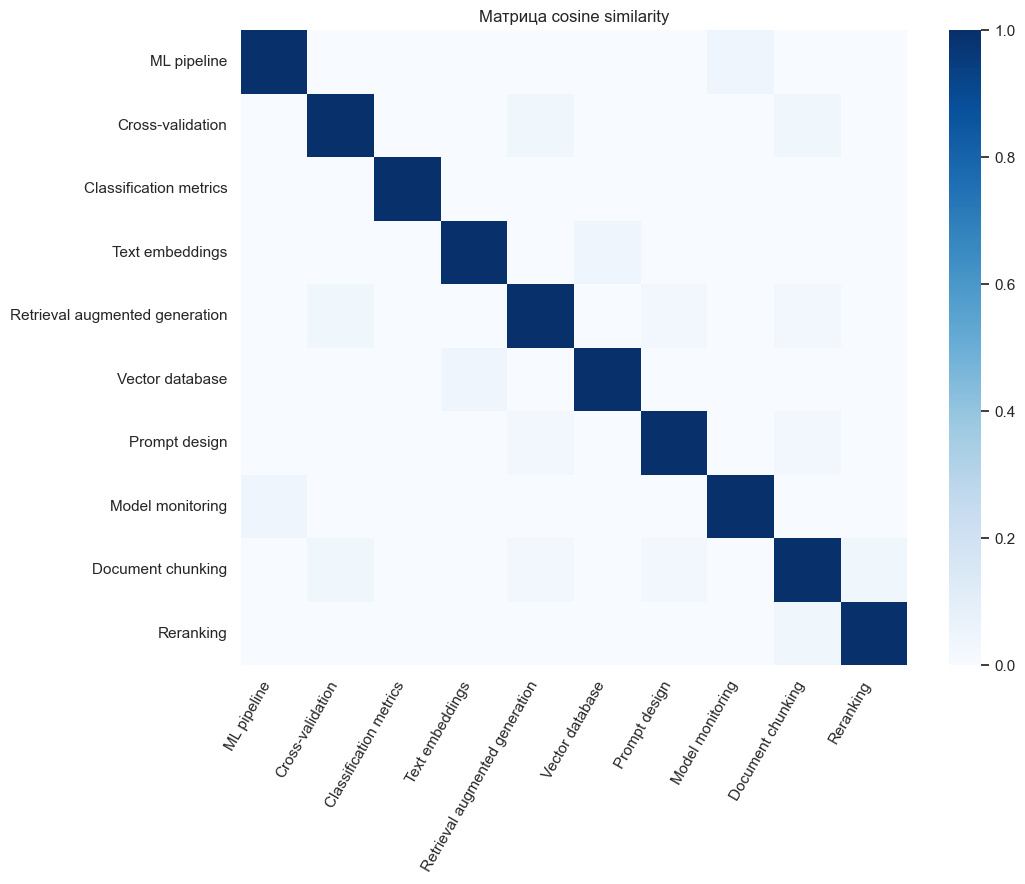

In [6]:
document_similarity = cosine_similarity(document_matrix)

plt.figure(figsize=(11, 9))
sns.heatmap(
    document_similarity,
    xticklabels=documents["title"],
    yticklabels=documents["title"],
    cmap="Blues",
    vmin=0,
    vmax=1,
)
plt.title("Матрица cosine similarity")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Наиболее важные термы

In [7]:
terms = vectorizer.get_feature_names_out()
term_rows = []
for index, row in documents.iterrows():
    weights = document_matrix[index].toarray().ravel()
    top_indices = weights.argsort()[-5:][::-1]
    term_rows.append({
        "document": row["title"],
        "top_terms": ", ".join(terms[top_indices]),
    })

pd.DataFrame(term_rows)

,document,top_terms
0,ML pipeline,"признаков, объединяет, снижая, подготовку, под..."
1,Cross-validation,"оценивает устойчивость, модели на, выборки, ва..."
2,Classification metrics,"auc, recall, качества классификатора, стороны,..."
3,Text embeddings,"текстовые embeddings, фрагмента числовым, вект..."
4,Retrieval augmented generation,"языковой модели, rag сначала, находит релевант..."
5,Vector database,"выполняет быстрый, выполняет, ближайших, ближа..."
6,Prompt design,"формат, ожидаемого ответа, ограничения формат,..."
7,Model monitoring,"качество, входных данных, отслеживает, задержк..."
8,Document chunking,"небольшие, небольшие фрагменты, документы деля..."
9,Reranking,"найденные, reranker, документы повышает, найде..."


## Контекст для передачи в LLM

In [8]:
context = "\n\n".join(
    f"[{row.title}] {row.text}"
    for row in results.itertuples()
)
print(context)

[Retrieval augmented generation] RAG сначала находит релевантный контекст, затем передаёт его языковой модели.

[Prompt design] Хороший prompt задаёт роль, контекст, ограничения и формат ожидаемого ответа.

[Cross-validation] Кросс-валидация оценивает устойчивость модели на нескольких разбиениях выборки.


## Вывод

TF-IDF даёт прозрачный lexical baseline: легко увидеть веса слов и объяснить результат поиска. Метод плохо понимает синонимы и смысловые перефразирования, поэтому следующий шаг для LLM/RAG — embeddings, векторная база, оценка recall@k и reranking.

## Расширенная оценка retrieval

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

### Набор проверочных запросов

In [10]:
evaluation_queries = pd.DataFrame([
    ("как проверить устойчивость модели", "cross-validation"),
    ("что передать языковой модели как найденный контекст", "rag"),
    ("где хранить векторы документов", "vector-database"),
    ("как разбивать длинный документ", "chunking"),
    ("как повторно отсортировать найденные фрагменты", "reranking"),
    ("как отслеживать ошибки и задержку", "monitoring"),
], columns=["query", "expected_id"])

evaluation_rows = []
for row in evaluation_queries.itertuples():
    query_results, query_scores = search(row.query, limit=3)
    retrieved_ids = query_results["id"].tolist()
    evaluation_rows.append({
        "query": row.query,
        "expected_id": row.expected_id,
        "top_1": retrieved_ids[0],
        "hit_at_1": row.expected_id == retrieved_ids[0],
        "hit_at_3": row.expected_id in retrieved_ids,
        "top_score": query_results.iloc[0]["score"],
    })

retrieval_evaluation = pd.DataFrame(evaluation_rows)
display(retrieval_evaluation)
pd.Series({
    "hit_at_1": retrieval_evaluation["hit_at_1"].mean(),
    "hit_at_3": retrieval_evaluation["hit_at_3"].mean(),
}).to_frame("value")

,query,expected_id,top_1,hit_at_1,hit_at_3,top_score
0,как проверить устойчивость модели,cross-validation,cross-validation,True,True,0.406888
1,что передать языковой модели как найденный кон...,rag,rag,True,True,0.423370
2,где хранить векторы документов,vector-database,vector-database,True,True,0.244539
3,как разбивать длинный документ,chunking,reranking,False,True,0.000000
4,как повторно отсортировать найденные фрагменты,reranking,reranking,True,True,0.282369
5,как отслеживать ошибки и задержку,monitoring,monitoring,True,True,0.368572


,value
hit_at_1,0.833333
hit_at_3,1.000000


### Сравнение способов векторизации

,vectorizer,vocabulary_size,hit_at_1,density
0,word_1,83,0.833333,0.108434
1,word_1_2,163,0.833333,0.104294
2,char_3_5,1474,1.000000,0.122931


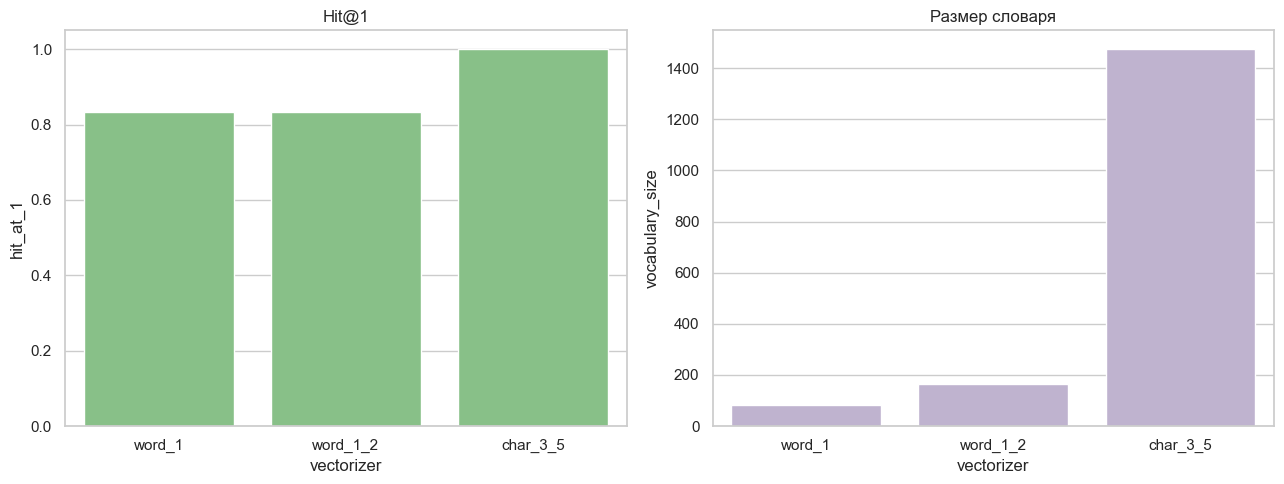

In [11]:
vectorizer_configs = {
    "word_1": TfidfVectorizer(ngram_range=(1, 1)),
    "word_1_2": TfidfVectorizer(ngram_range=(1, 2)),
    "char_3_5": TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)),
}

config_rows = []
for config_name, candidate_vectorizer in vectorizer_configs.items():
    candidate_matrix = candidate_vectorizer.fit_transform(documents["text"])
    hits = []
    for row in evaluation_queries.itertuples():
        query_vector = candidate_vectorizer.transform([row.query])
        similarities = cosine_similarity(query_vector, candidate_matrix).ravel()
        predicted_id = documents.iloc[int(similarities.argmax())]["id"]
        hits.append(predicted_id == row.expected_id)
    config_rows.append({
        "vectorizer": config_name,
        "vocabulary_size": candidate_matrix.shape[1],
        "hit_at_1": np.mean(hits),
        "density": candidate_matrix.nnz / (candidate_matrix.shape[0] * candidate_matrix.shape[1]),
    })

vectorizer_comparison = pd.DataFrame(config_rows)
display(vectorizer_comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=vectorizer_comparison, x="vectorizer", y="hit_at_1", ax=axes[0], color="#7fc97f")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Hit@1")
sns.barplot(data=vectorizer_comparison, x="vectorizer", y="vocabulary_size", ax=axes[1], color="#beaed4")
axes[1].set_title("Размер словаря")
plt.tight_layout()
plt.show()

### Порог уверенности и отказ от ответа

In [12]:
threshold = 0.12
fallback_rows = []
for current_query in [
    "как найти контекст для языковой модели",
    "где хранить embeddings",
    "какая погода будет завтра",
    "рецепт яблочного пирога",
]:
    current_results, current_scores = search(current_query, limit=1)
    top_result = current_results.iloc[0]
    fallback_rows.append({
        "query": current_query,
        "top_document": top_result["id"],
        "score": top_result["score"],
        "decision": "retrieve" if top_result["score"] >= threshold else "fallback",
    })

pd.DataFrame(fallback_rows)

,query,top_document,score,decision
0,как найти контекст для языковой модели,rag,0.423370,retrieve
1,где хранить embeddings,embeddings,0.238329,retrieve
2,какая погода будет завтра,reranking,0.000000,fallback
3,рецепт яблочного пирога,reranking,0.000000,fallback


### Покрытие словаря запросом

,query,tokens,known_tokens,coverage
0,как проверить устойчивость модели,4,2,0.500000
1,что передать языковой модели как найденный кон...,7,3,0.428571
2,где хранить векторы документов,4,1,0.250000
3,как разбивать длинный документ,4,0,0.000000
4,как повторно отсортировать найденные фрагменты,5,3,0.600000
5,как отслеживать ошибки и задержку,5,2,0.400000


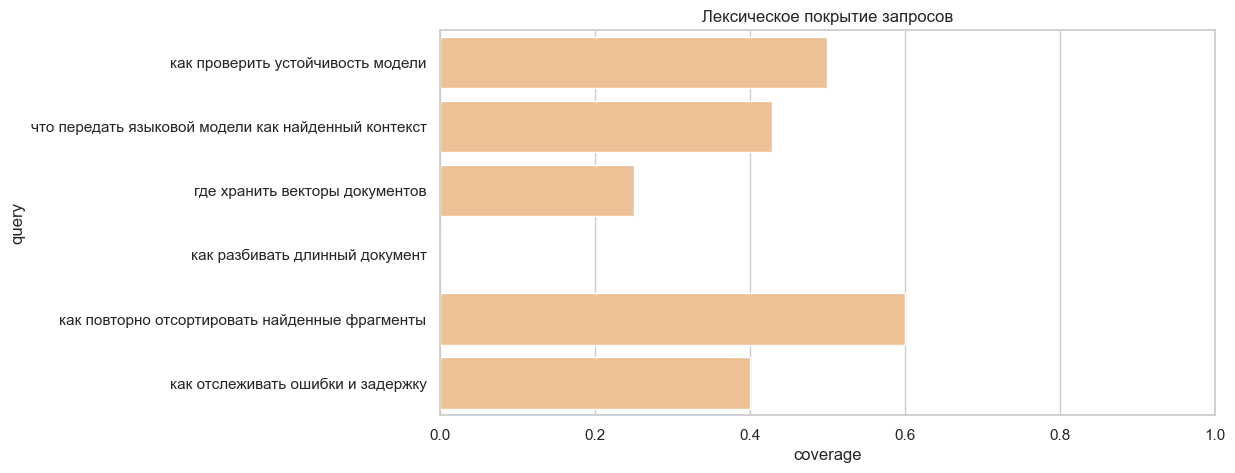

In [13]:
vocabulary = set(vectorizer.get_feature_names_out())
coverage_rows = []
for current_query in evaluation_queries["query"]:
    normalized_tokens = current_query.lower().split()
    known_tokens = [token for token in normalized_tokens if token in vocabulary]
    coverage_rows.append({
        "query": current_query,
        "tokens": len(normalized_tokens),
        "known_tokens": len(known_tokens),
        "coverage": len(known_tokens) / len(normalized_tokens),
    })

coverage = pd.DataFrame(coverage_rows)
display(coverage)

plt.figure(figsize=(10, 5))
sns.barplot(data=coverage, x="coverage", y="query", color="#fdc086")
plt.xlim(0, 1)
plt.title("Лексическое покрытие запросов")
plt.show()

### Анализ ошибок

In [14]:
retrieval_evaluation[~retrieval_evaluation["hit_at_1"]][
    ["query", "expected_id", "top_1", "top_score", "hit_at_3"]
]

,query,expected_id,top_1,top_score,hit_at_3
3,как разбивать длинный документ,chunking,reranking,0.0,True


### Итог расширенного анализа

Retrieval нужно проверять на размеченном наборе запросов через Hit@k или Recall@k. Word- и character-N-граммы по-разному реагируют на формы слов и опечатки. Порог уверенности позволяет отказаться от нерелевантного контекста, а низкое покрытие словаря указывает, где lexical-поиск нужно заменить embeddings или гибридной схемой.